## HR Employee Attrition Analysis

This notebook documents the complete Python Data Analysis challenge using the **HR Employee Attrition** dataset.

### Contents
1. Dataset description
2. Data cleaning
3. Key formulas/functions
4. Visualizations
5. Web-scraping integration
6. Insights and recommendations
7. Final project outputs


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the main HR dataset
df = pd.read_excel("/content/HR-Employee-Attrition.xlsx")

In [4]:
print("Rows:", df.shape[0])

Rows: 1470


In [5]:
print("Columns:", df.shape[1])

Columns: 35


In [6]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 1. Dataset Description

The HR Employee Attrition dataset contains employee-level information such as:

- Age
- Department
- Job Role
- Job Level
- Monthly Income
- Job Satisfaction
- Years at Company
- Total Working Years
- Overtime
- Attrition

The target variable **Attrition** indicates whether an employee left the organization.


In [7]:
# Dataset structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
print("\nStatistical summary:")
display(df.describe(include="all").T)


Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


## 2. Cleaning Steps

The main cleaning workflow includes:

- Detecting duplicate rows
- Checking missing values
- Removing duplicate records
- Filling numerical missing values with the median when required
- Filling categorical missing values with the mode when required
- Checking data types
- Preparing grouped summary tables


In [10]:
# Duplicate check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Remove duplicates
df = df.drop_duplicates().copy()

In [12]:
# Missing values
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
# Handle numerical missing values
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

In [14]:
# Handle categorical missing values
categorical_columns = df.select_dtypes(exclude=np.number).columns
for col in categorical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
print(df.isnull().sum().sum())

0


## 3. Key Formulas / Functions Used

### Mean
Average value of a numerical column.

`df["Age"].mean()`

### Median
Middle value after sorting.

`df["MonthlyIncome"].median()`

### Standard deviation
Measures the spread of numerical values.

`df["MonthlyIncome"].std()`

### Grouping
Used to compare employee groups.

`df.groupby("Department")["MonthlyIncome"].mean()`

### Attrition rate

`Attrition Rate = Employees with Attrition = Yes / Total Employees × 100`

### NumPy functions
`np.mean()`, `np.sum()`, `np.std()`, `np.argmax()`, `np.argmin()`

### Pandas functions
`head()`, `tail()`, `info()`, `describe()`, `value_counts()`, `dropna()`, `fillna()`, `drop_duplicates()`, `groupby()`, `merge()`, `concat()`

### Visualization libraries
Matplotlib, Seaborn and Plotly were used during the challenge.


In [16]:
# Calculate key HR metrics
total_employees = len(df)

In [17]:
attrition_count = (df["Attrition"] == "Yes").sum()

In [18]:
attrition_rate = attrition_count / total_employees * 100

In [19]:
print(f"Total employees: {total_employees}")

Total employees: 1470


In [20]:
print(f"Employees who left: {attrition_count}")

Employees who left: 237


In [21]:
print(f"Attrition rate: {attrition_rate:.2f}%")

Attrition rate: 16.12%


In [22]:
department_summary = df.groupby("Department").agg(
    Employee_Count=("EmployeeNumber", "count"),
    Average_Income=("MonthlyIncome", "mean"),
    Average_Age=("Age", "mean")
).reset_index()

In [23]:
display(department_summary)

,Department,Employee_Count,Average_Income,Average_Age
0,Human Resources,63,6654.507937,37.809524
1,Research & Development,961,6281.252862,37.042664
2,Sales,446,6959.172646,36.542601


## 4. Visualizations


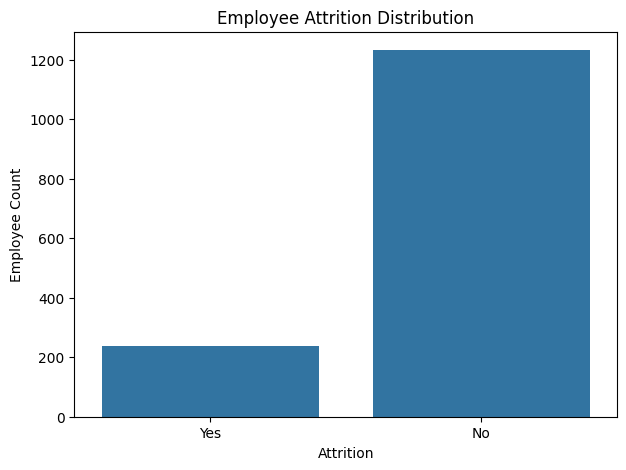

In [24]:
# Attrition distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.show()

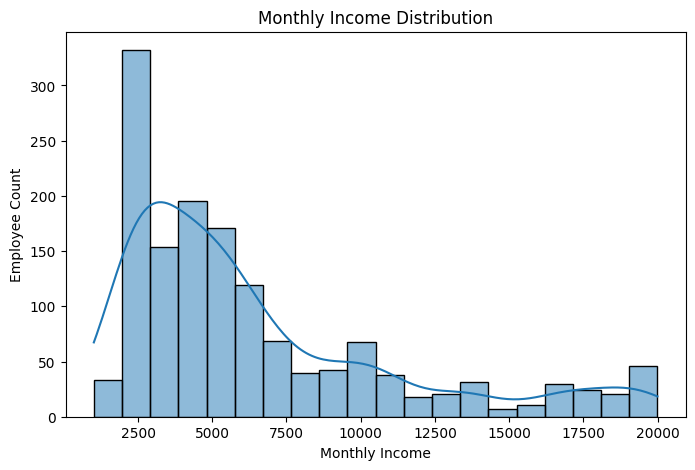

In [25]:
# Monthly income distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="MonthlyIncome", kde=True)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Employee Count")
plt.show()

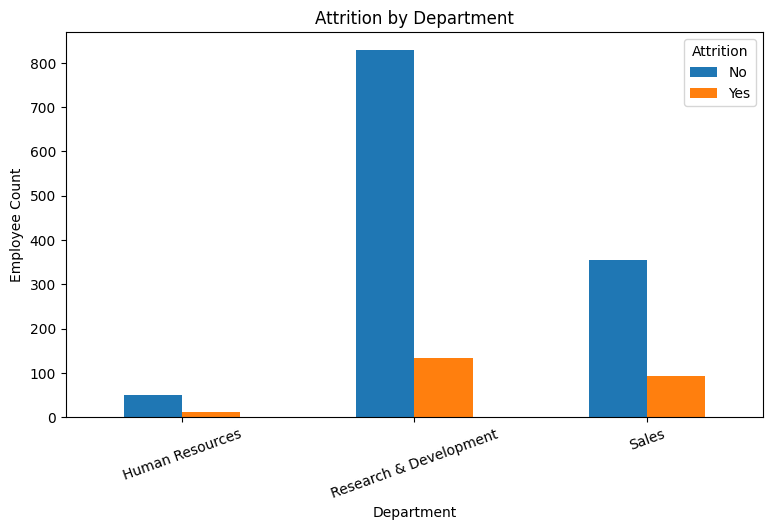

In [26]:
# Attrition by department
department_attrition = pd.crosstab(df["Department"], df["Attrition"])

department_attrition.plot(kind="bar", figsize=(9, 5))
plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.xticks(rotation=20)
plt.show()

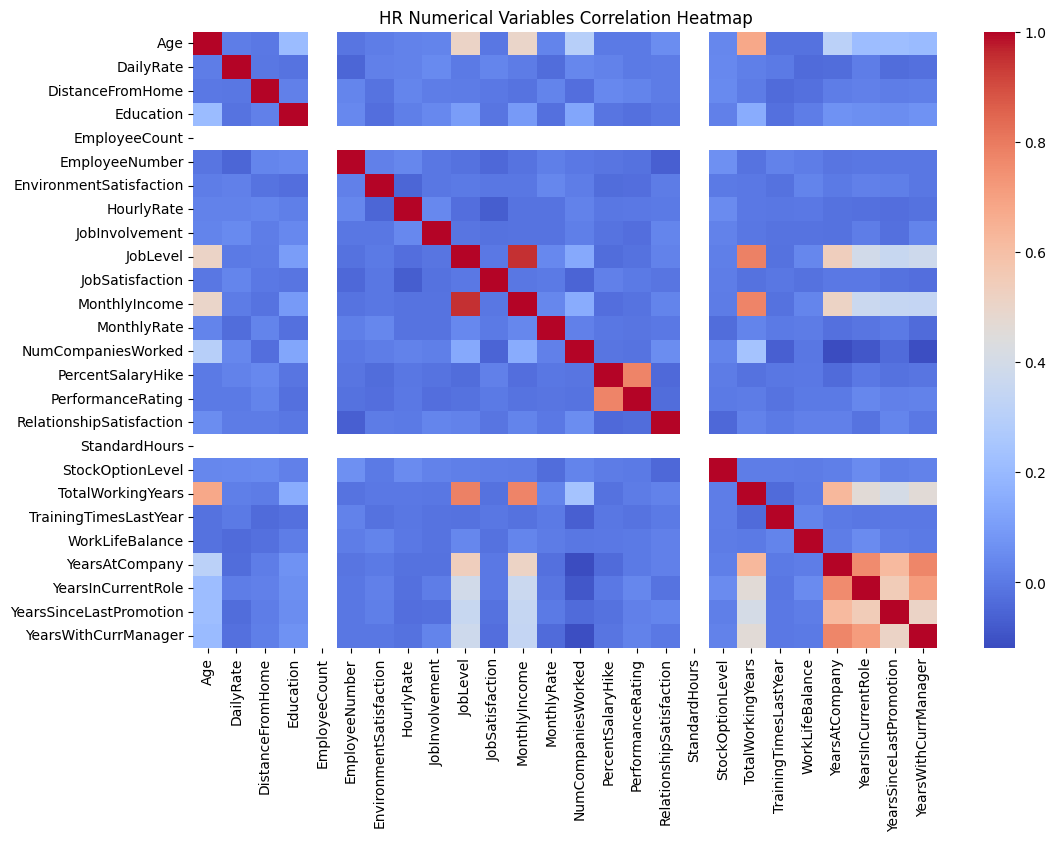

In [27]:
# Correlation heatmap
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("HR Numerical Variables Correlation Heatmap")
plt.show()


## 5. Web-Scraping Integration

Days 7 and 8 introduced external web data using `requests` and `BeautifulSoup`.

The practice website used was **Books to Scrape**. Book titles, prices and links were extracted and converted into DataFrames.

Because the HR dataset and the scraped book dataset do not have a legitimate common key, the data is retained as a **supplementary external data source** rather than performing a meaningless row-level merge.

This is an important data-analysis principle: **never merge datasets simply to satisfy a requirement; merge only when the relationship between records is valid.**


In [31]:
from pathlib import Path

web_file = Path("scraped_books_day8.csv")

In [32]:
if web_file.exists():
    web_df = pd.read_csv(web_file)
    print("Web dataset loaded:", web_df.shape)
    display(web_df.head())

    web_summary = pd.DataFrame({
        "Web Records": [len(web_df)],
        "Average Price": [web_df["Price"].mean()],
        "Minimum Price": [web_df["Price"].min()],
        "Maximum Price": [web_df["Price"].max()]
    })
    display(web_summary)
else:
    print("scraped_books_day9.csv was not found.")
    print("Run Day 9 first if you want the web-scraping output in this notebook.")


scraped_books_day9.csv was not found.
Run Day 9 first if you want the web-scraping output in this notebook.


## 6. Key Insights

The following points should be interpreted from the actual output after running the notebook:

1. The overall employee attrition rate can be calculated using the `Attrition` column.
2. Department-level summaries show differences in employee count and average income.
3. The income distribution helps identify the spread of employee salaries and potential outliers.
4. The attrition-by-department chart helps identify departments requiring deeper investigation.
5. Correlation analysis helps identify numerical variables that move together, but correlation does not prove causation.
6. Web scraping demonstrates how external real-world information can be collected and prepared for analysis.


## 7. Recommendations

- Investigate departments or job roles with comparatively high attrition.
- Examine overtime, job satisfaction, income and years at company when studying employee retention.
- Use employee segmentation to identify groups with higher attrition risk.
- Monitor attrition trends regularly instead of relying on a one-time analysis.
- Validate external web data before using it for business decisions.
- Maintain a clear data dictionary and document every cleaning and transformation step.

### Final Conclusion

This project demonstrates an end-to-end Python data-analysis workflow: NumPy operations, Pandas data manipulation, data cleaning, descriptive statistics, Matplotlib/Seaborn/Plotly visualization, web scraping with Requests and BeautifulSoup, and final business insights.



In [33]:
# Save the final cleaned HR dataset
df.to_csv("HR_Employee_Attrition_Cleaned.csv", index=False)

In [34]:
# Save a summary report table
final_summary = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Employees with Attrition",
        "Attrition Rate (%)",
        "Average Age",
        "Average Monthly Income"
    ],
    "Value": [
        total_employees,
        attrition_count,
        round(attrition_rate, 2),
        round(df["Age"].mean(), 2),
        round(df["MonthlyIncome"].mean(), 2)
    ]
})

In [35]:
final_summary.to_csv("HR_Final_Summary.csv", index=False)

In [36]:
display(final_summary)

,Metric,Value
0,Total Employees,1470.00
1,Employees with Attrition,237.00
2,Attrition Rate (%),16.12
3,Average Age,36.92
4,Average Monthly Income,6502.93
